### Model display config
```
   enabled     – bool: include model in figure
   color       – matplotlib colour string
   label       – legend entry
   alpha_outer – opacity of the 95% PI band (default 0.15)
   alpha_inner – opacity of the 50% PI band (default 0.35)
   zorder      – drawing order (higher = drawn on top)
```

In [21]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt

import src.plotting as P
import src.colouring as C
import src.scoring as S
from hub_config import COVID_HUB, FLU_HUB, RSV_HUB

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 15,          # base size
    "axes.titlesize": 20,     # subplot title
    "axes.labelsize": 20,     # x/y axis labels
    "xtick.labelsize": 18,    # x tick labels
    "ytick.labelsize": 18,    # y tick labels
    "legend.fontsize": 20,    # legend text
    "legend.title_fontsize": 20,
    "figure.titlesize": 20,   # suptitle
})

PLTS_TO = 'figures/hubs'
os.makedirs(PLTS_TO, exist_ok=True)

# plot_every_n:
N = 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Location names from flu obs file
_flu_truth_raw = pd.read_parquet(FLU_HUB.truth_path)
LOCATION_NAMES = (
    _flu_truth_raw[["location", "location_name"]]
    .dropna()
    .drop_duplicates("location")
    .set_index("location")["location_name"]
    .to_dict()
)
del _flu_truth_raw
print(f"Loaded {len(LOCATION_NAMES)} location names.")

Loaded 53 location names.


---
## Flu

In [23]:
flu_fc = pd.read_parquet(FLU_HUB.forecasts_path)

# Truth: flu truth has a 'wk inc flu hosp' target with NaN output_type = point obs
_flu_truth_raw = pd.read_parquet(FLU_HUB.truth_path)
flu_obs = (
    _flu_truth_raw[
        (_flu_truth_raw["target"] == "wk inc flu hosp")
        & _flu_truth_raw["output_type"].isna()
    ]
    [["target_end_date", "location", "value"]]
    .drop_duplicates(["target_end_date", "location"])
    .query("target_end_date >= @FLU_HUB.season_start and target_end_date <= @FLU_HUB.season_end")
)
del _flu_truth_raw
print(f"Flu forecasts: {len(flu_fc):,} rows | obs: {len(flu_obs):,} rows across {flu_obs.location.nunique()} locations")

Flu forecasts: 10,047,950 rows | obs: 1,484 rows across 53 locations


In [24]:
_flu_all_models = sorted(flu_fc["model_id"].unique())
_flu_featured   = {FLU_HUB.ensemble_id, FLU_HUB.google_id, FLU_HUB.baseline_id} | set(FLU_HUB.extra_ensemble_ids)

FLU_MODEL_DISPLAY = {
    FLU_HUB.ensemble_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "FluSight Ensemble",
        "zorder":  2,
    },
    FLU_HUB.google_id: {
        "enabled": True,
        "color":   C.GOOGLE_PINK,
        "label":   "Google SAI",
        "zorder":  3,
    },
    FLU_HUB.baseline_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "FluSight Baseline",
    },
    **{
        mid: {"enabled": False, "color": C.OTHER_GREY, "label": mid}
        for mid in FLU_HUB.extra_ensemble_ids
    },
    **{
        mid: {"enabled": False, "color": C.OTHER_GREY, "label": mid}
        for mid in _flu_all_models
        if mid not in _flu_featured
    },
}

print("Enabled models:", [m for m, c in FLU_MODEL_DISPLAY.items() if c["enabled"]])

Enabled models: ['Google_SAI-FluEns']


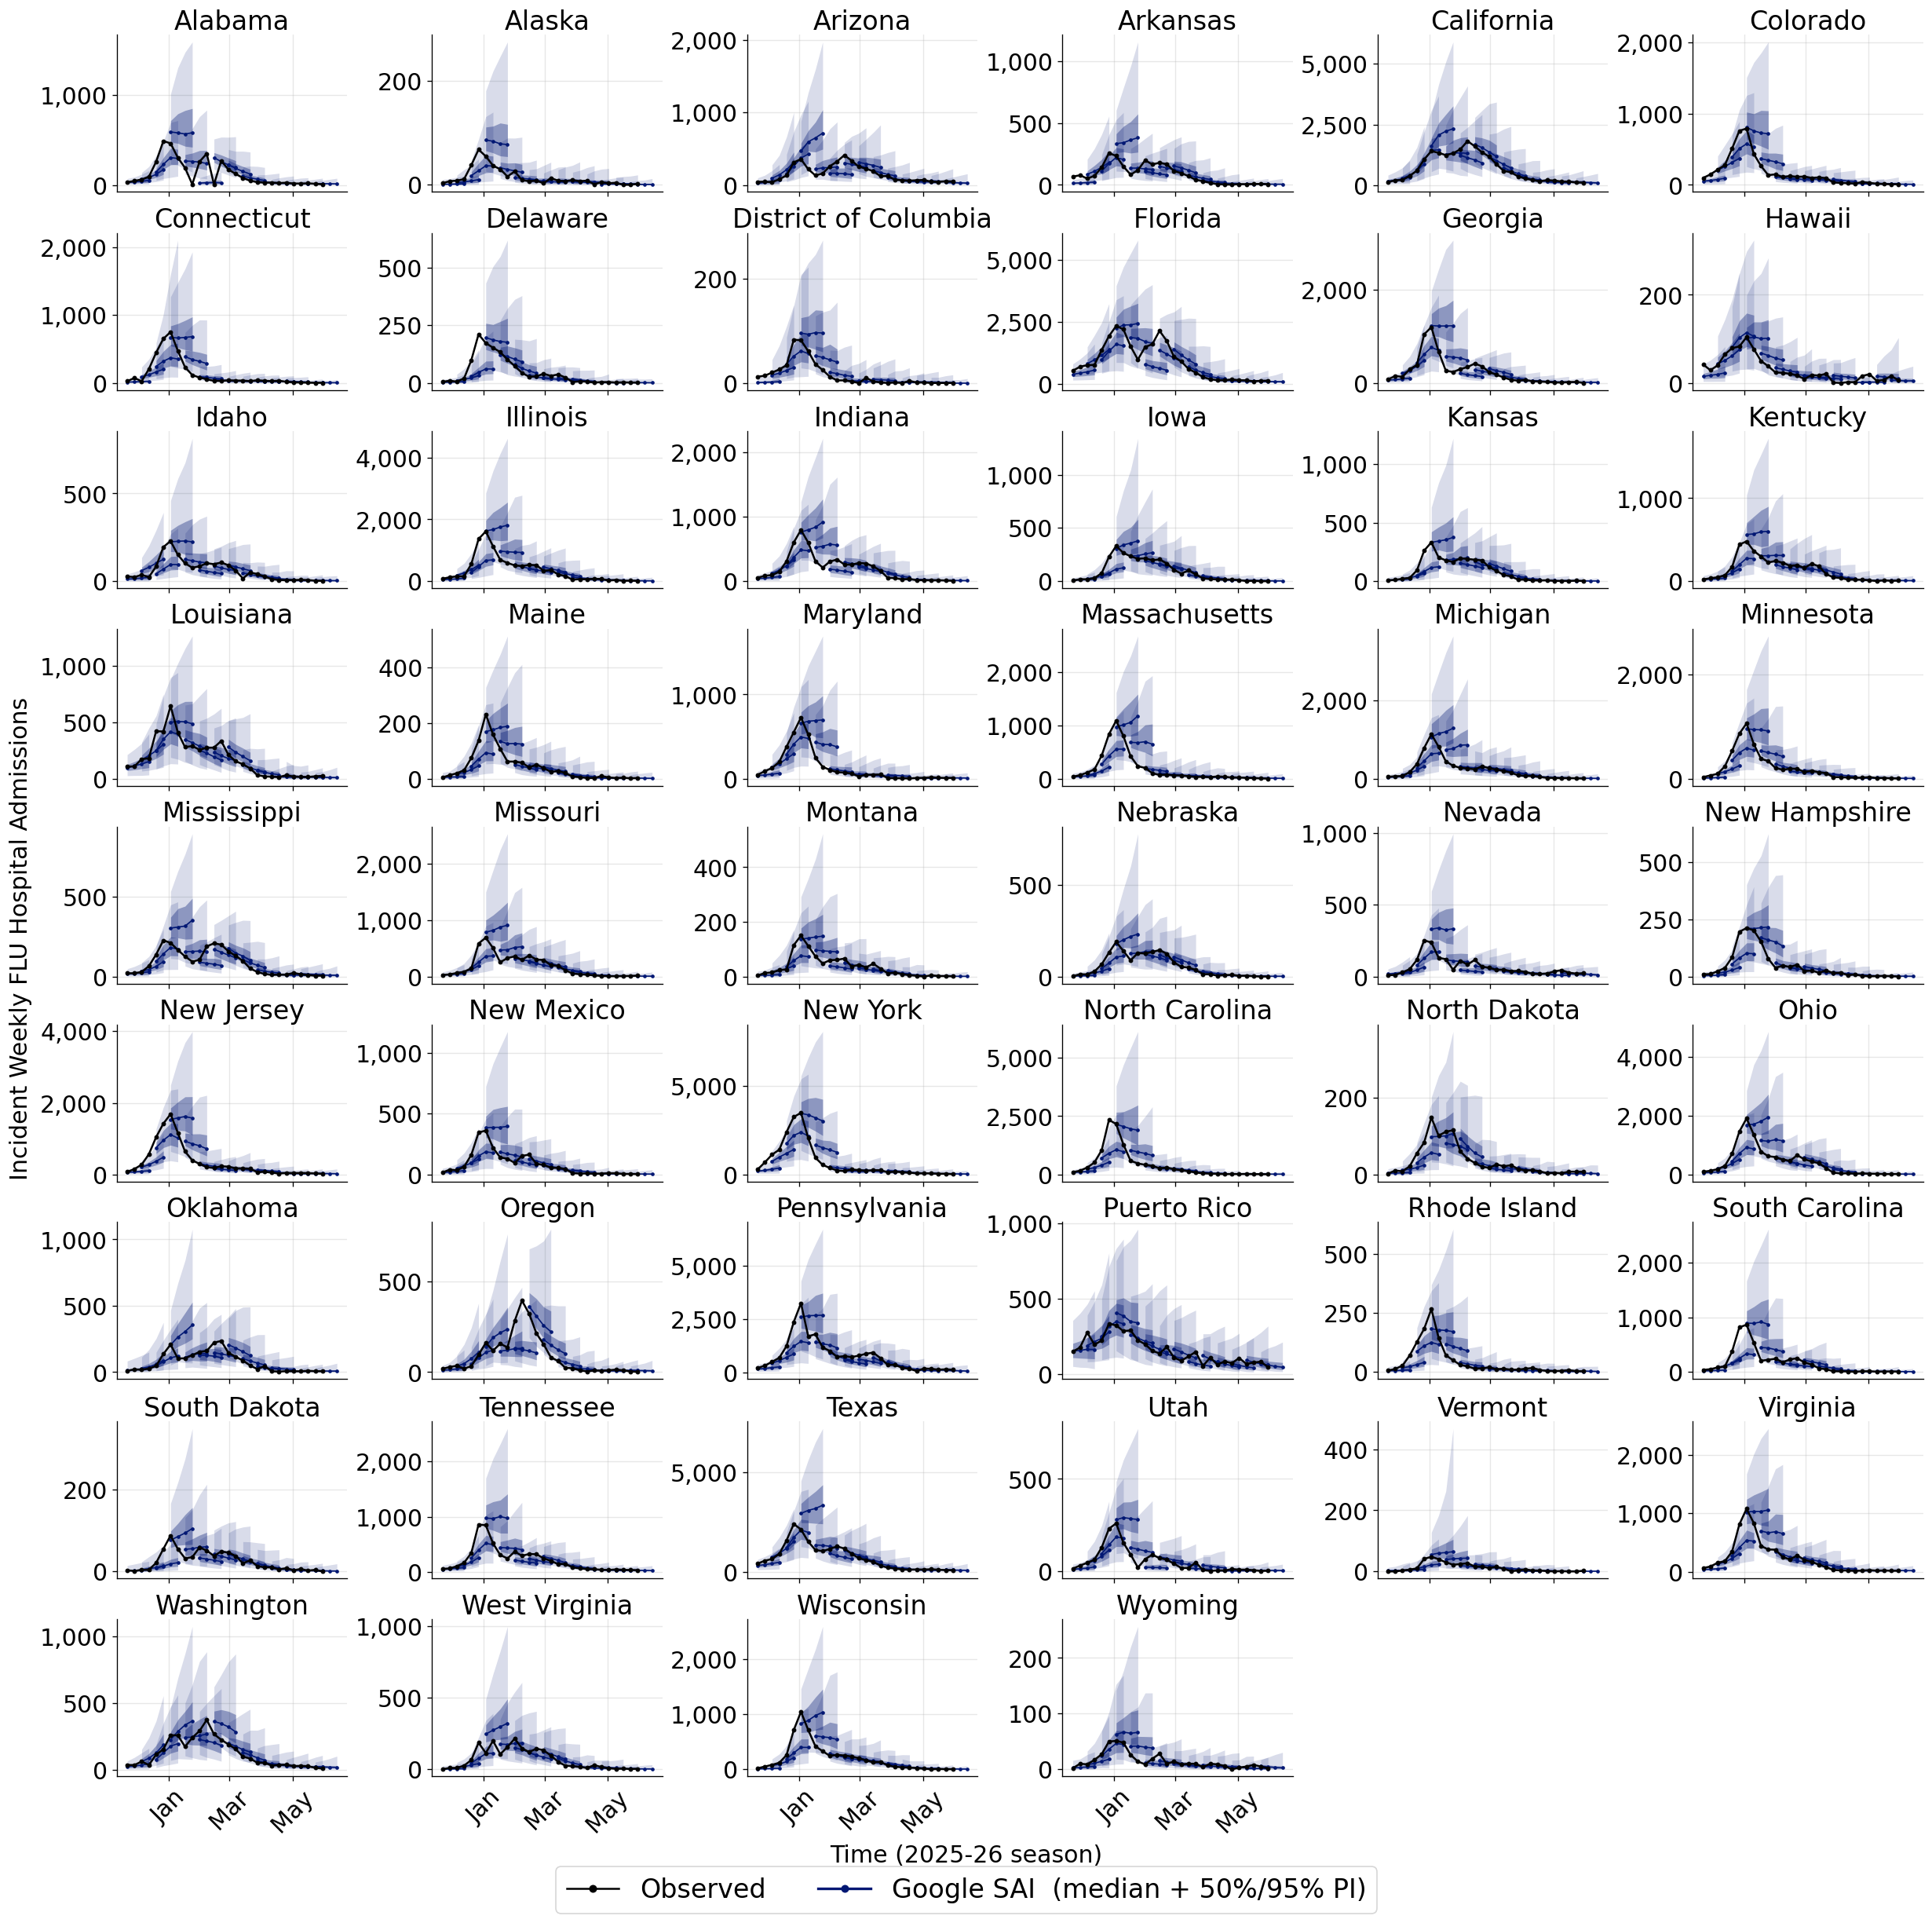

In [25]:
disease = "flu"
P.plot_forecast_fans(
    forecasts=flu_fc,
    truth=flu_obs,
    model_display=FLU_MODEL_DISPLAY,
    hub_label=FLU_HUB.label,
    location_names=LOCATION_NAMES,
    plot_every_n=2,
    save_path=os.path.join(PLTS_TO+f"/{disease}", f"{disease}_forecasts_over_season.png")
)

---
## COVID-19

In [26]:
covid_fc = pd.read_parquet(COVID_HUB.forecasts_path)

# Truth: point observations filtered to season window
_covid_truth_raw = pd.read_parquet(COVID_HUB.truth_path)
covid_obs = (
    _covid_truth_raw[_covid_truth_raw["output_type"].isna()]
    [["target_end_date", "location", "value"]]
    .drop_duplicates(["target_end_date", "location"])
    .query("target_end_date >= @COVID_HUB.season_start and target_end_date <= @COVID_HUB.season_end")
)
del _covid_truth_raw
print(f"COVID forecasts: {len(covid_fc):,} rows | obs: {len(covid_obs):,} rows across {covid_obs.location.nunique()} locations")

COVID forecasts: 2,895,980 rows | obs: 1,325 rows across 53 locations


In [27]:
_covid_all_models = sorted(covid_fc["model_id"].unique())
_covid_featured   = {COVID_HUB.ensemble_id, COVID_HUB.google_id, COVID_HUB.baseline_id}

COVID_MODEL_DISPLAY = {
    COVID_HUB.ensemble_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "CovidHub Ensemble",
        "zorder":  2,
    },
    COVID_HUB.google_id: {
        "enabled": True,
        "color":   C.GOOGLE_PINK,
        "label":   "GoogleSAI",
        "zorder":  3,
    },
    COVID_HUB.baseline_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "CovidHub Baseline",
    },
    **{
        mid: {"enabled": False, "color": C.OTHER_GREY, "label": mid}
        for mid in _covid_all_models
        if mid not in _covid_featured
    },
}

print("Enabled models:", [m for m, c in COVID_MODEL_DISPLAY.items() if c["enabled"]])

Enabled models: ['Google_SAI-Ensemble']


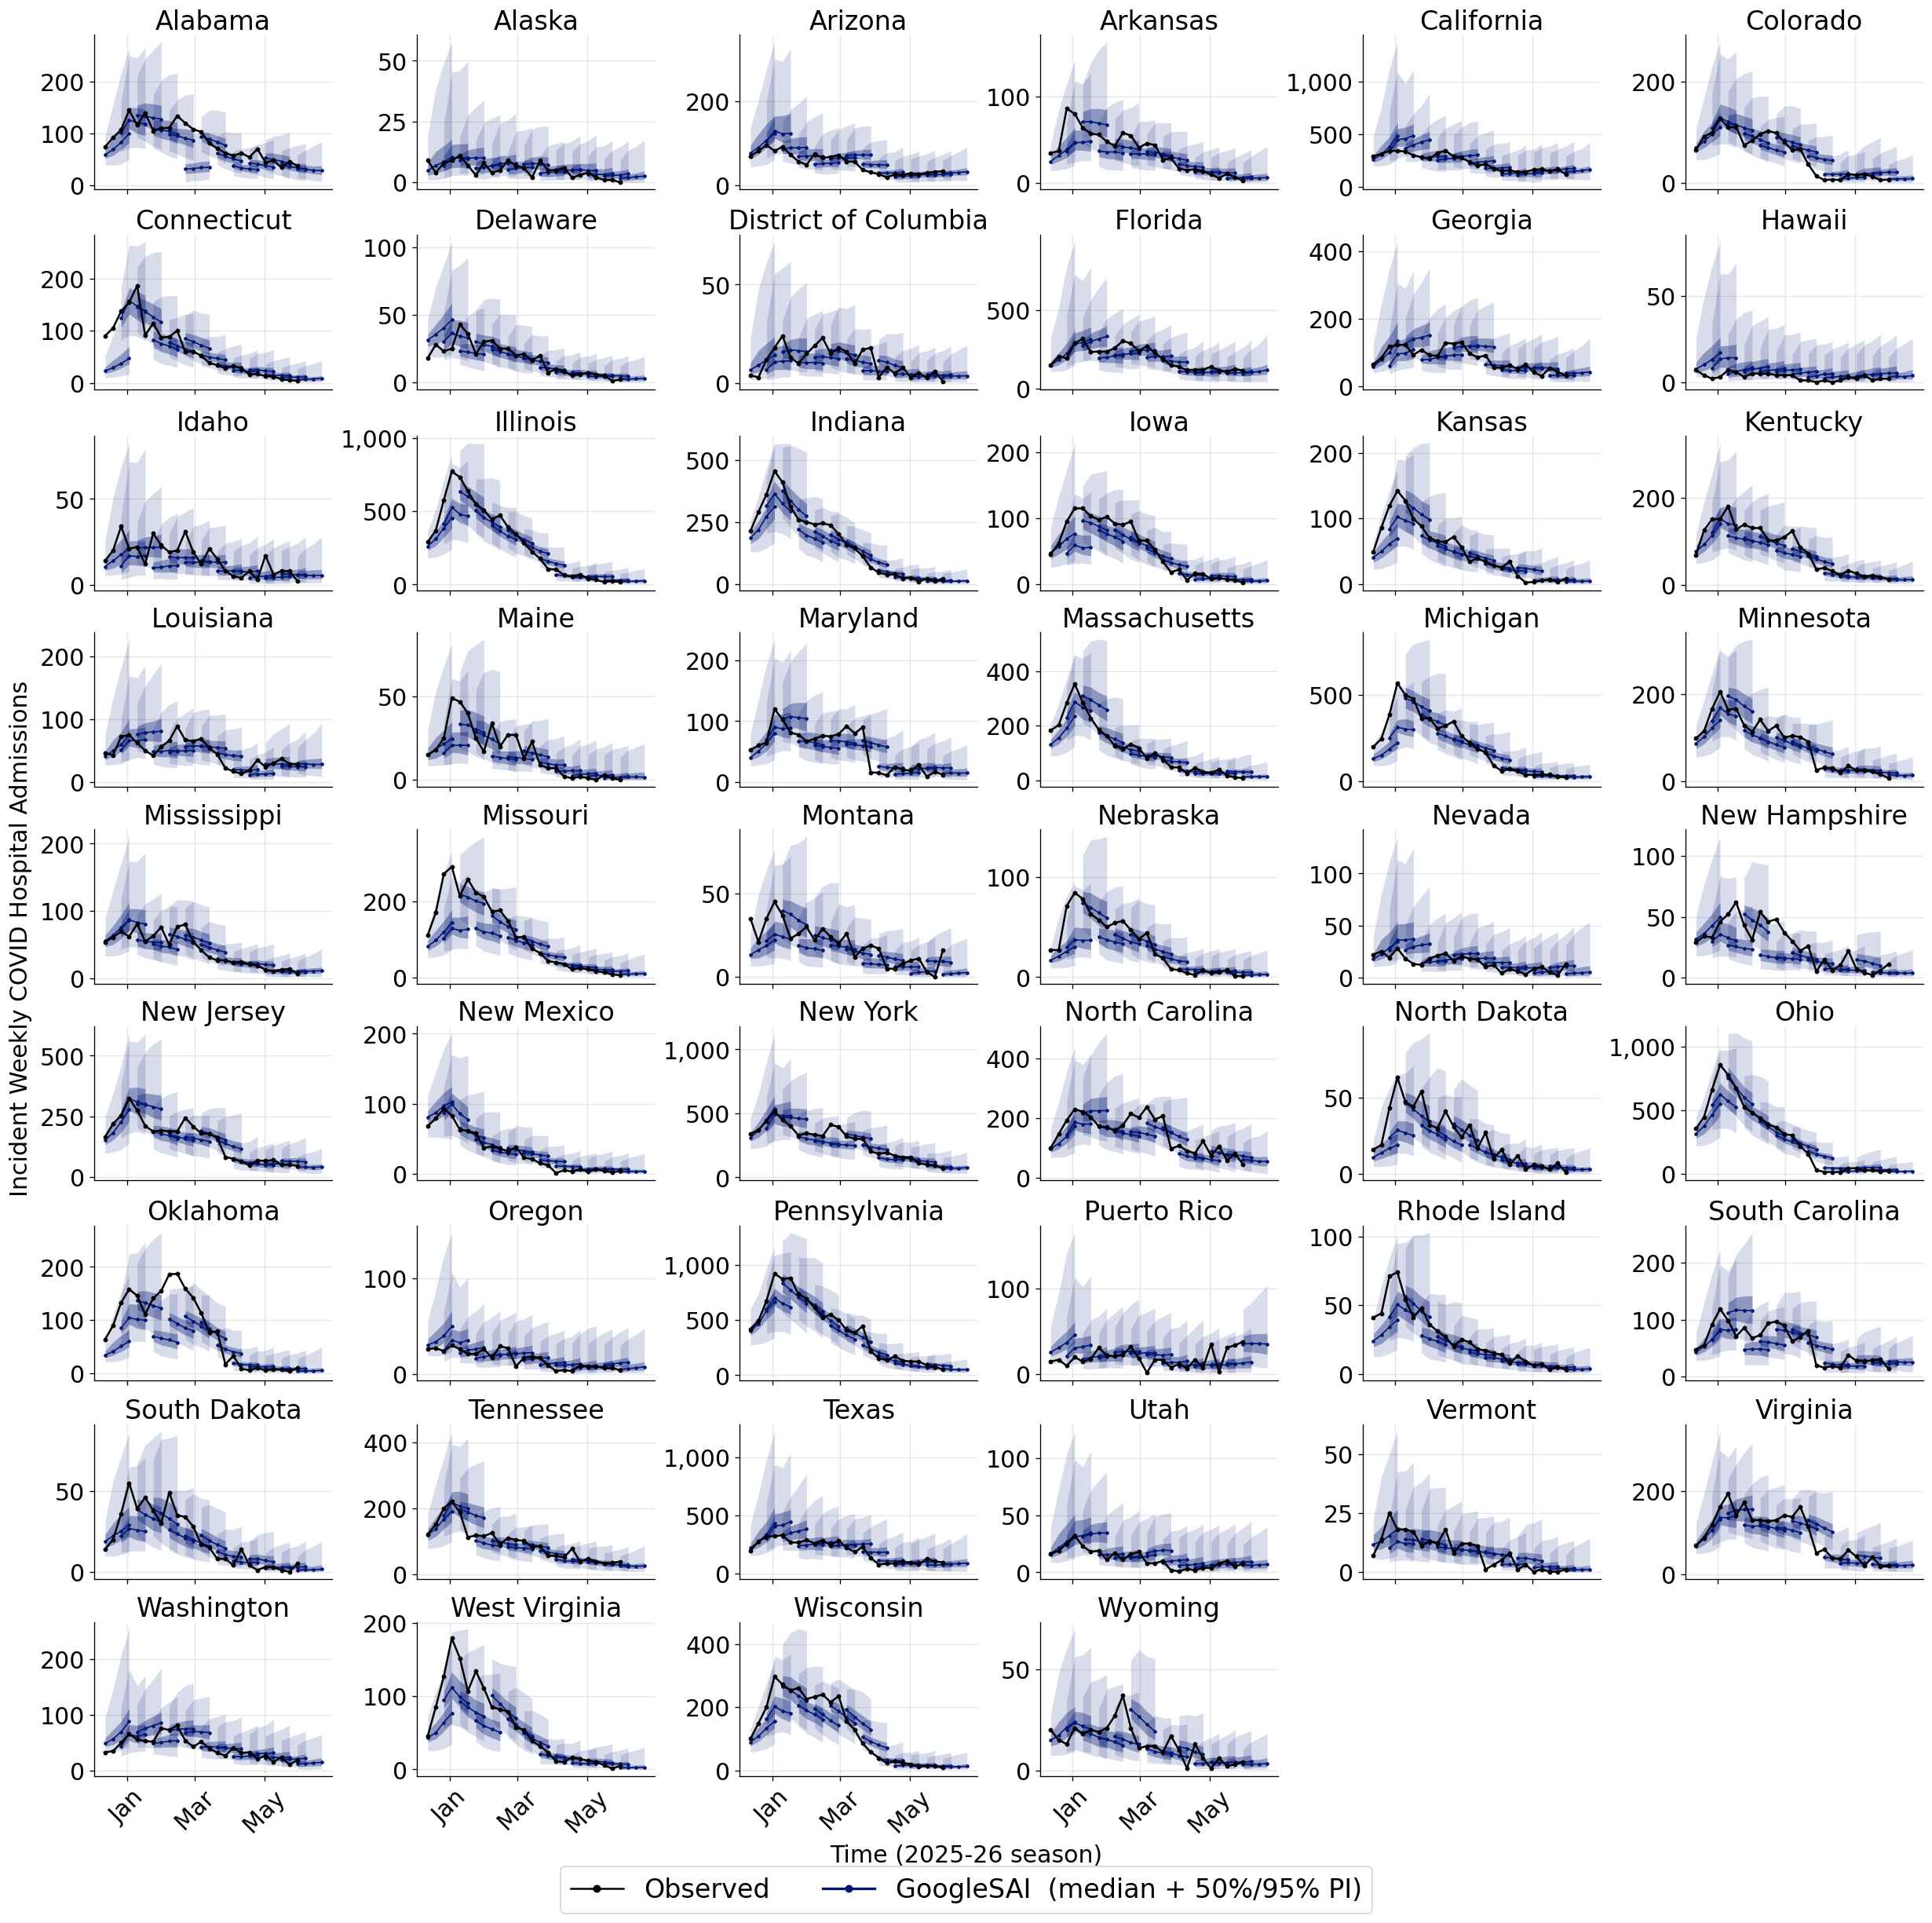

In [28]:
disease = "covid"
P.plot_forecast_fans(
    forecasts=covid_fc,
    truth=covid_obs,
    model_display=COVID_MODEL_DISPLAY,
    hub_label=COVID_HUB.label,
    location_names=LOCATION_NAMES,
    plot_every_n=N,
    save_path=os.path.join(PLTS_TO+f"/{disease}", f"{disease}_forecasts_over_season.png")
)

---
## RSV

In [29]:
rsv_fc = pd.read_parquet(RSV_HUB.forecasts_path)

# Truth: point observations only (NaN output_type rows), filtered to season window
_rsv_truth_raw = pd.read_parquet(RSV_HUB.truth_path)
rsv_obs = (
    _rsv_truth_raw[_rsv_truth_raw["output_type"].isna()]
    [["target_end_date", "location", "value"]]
    .drop_duplicates(["target_end_date", "location"])
    .query("target_end_date >= @RSV_HUB.season_start and target_end_date <= @RSV_HUB.season_end")
)
del _rsv_truth_raw
print(f"RSV forecasts: {len(rsv_fc):,} rows | obs: {len(rsv_obs):,} rows across {rsv_obs.location.nunique()} locations")

RSV forecasts: 1,471,463 rows | obs: 1,166 rows across 53 locations


In [30]:
_rsv_all_models = sorted(rsv_fc["model_id"].unique())
_rsv_featured   = {RSV_HUB.ensemble_id, RSV_HUB.google_id, RSV_HUB.baseline_id}

RSV_MODEL_DISPLAY = {
    RSV_HUB.ensemble_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "RSVHub Ensemble",
        "zorder":  2,
    },
    RSV_HUB.google_id: {
        "enabled": True,
        "color":   C.GOOGLE_PINK,
        "label":   "Google SAI",
        "zorder":  3,
    },
    RSV_HUB.baseline_id: {
        "enabled": False,
        "color":   C.HUB_BLACK,
        "label":   "RSVHub Baseline",
    },
    **{
        mid: {"enabled": False, "color": C.OTHER_GREY, "label": mid}
        for mid in _rsv_all_models
        if mid not in _rsv_featured
    },
}

print("Enabled models:", [m for m, c in RSV_MODEL_DISPLAY.items() if c["enabled"]])

Enabled models: ['Google_SAI-RSVEns']


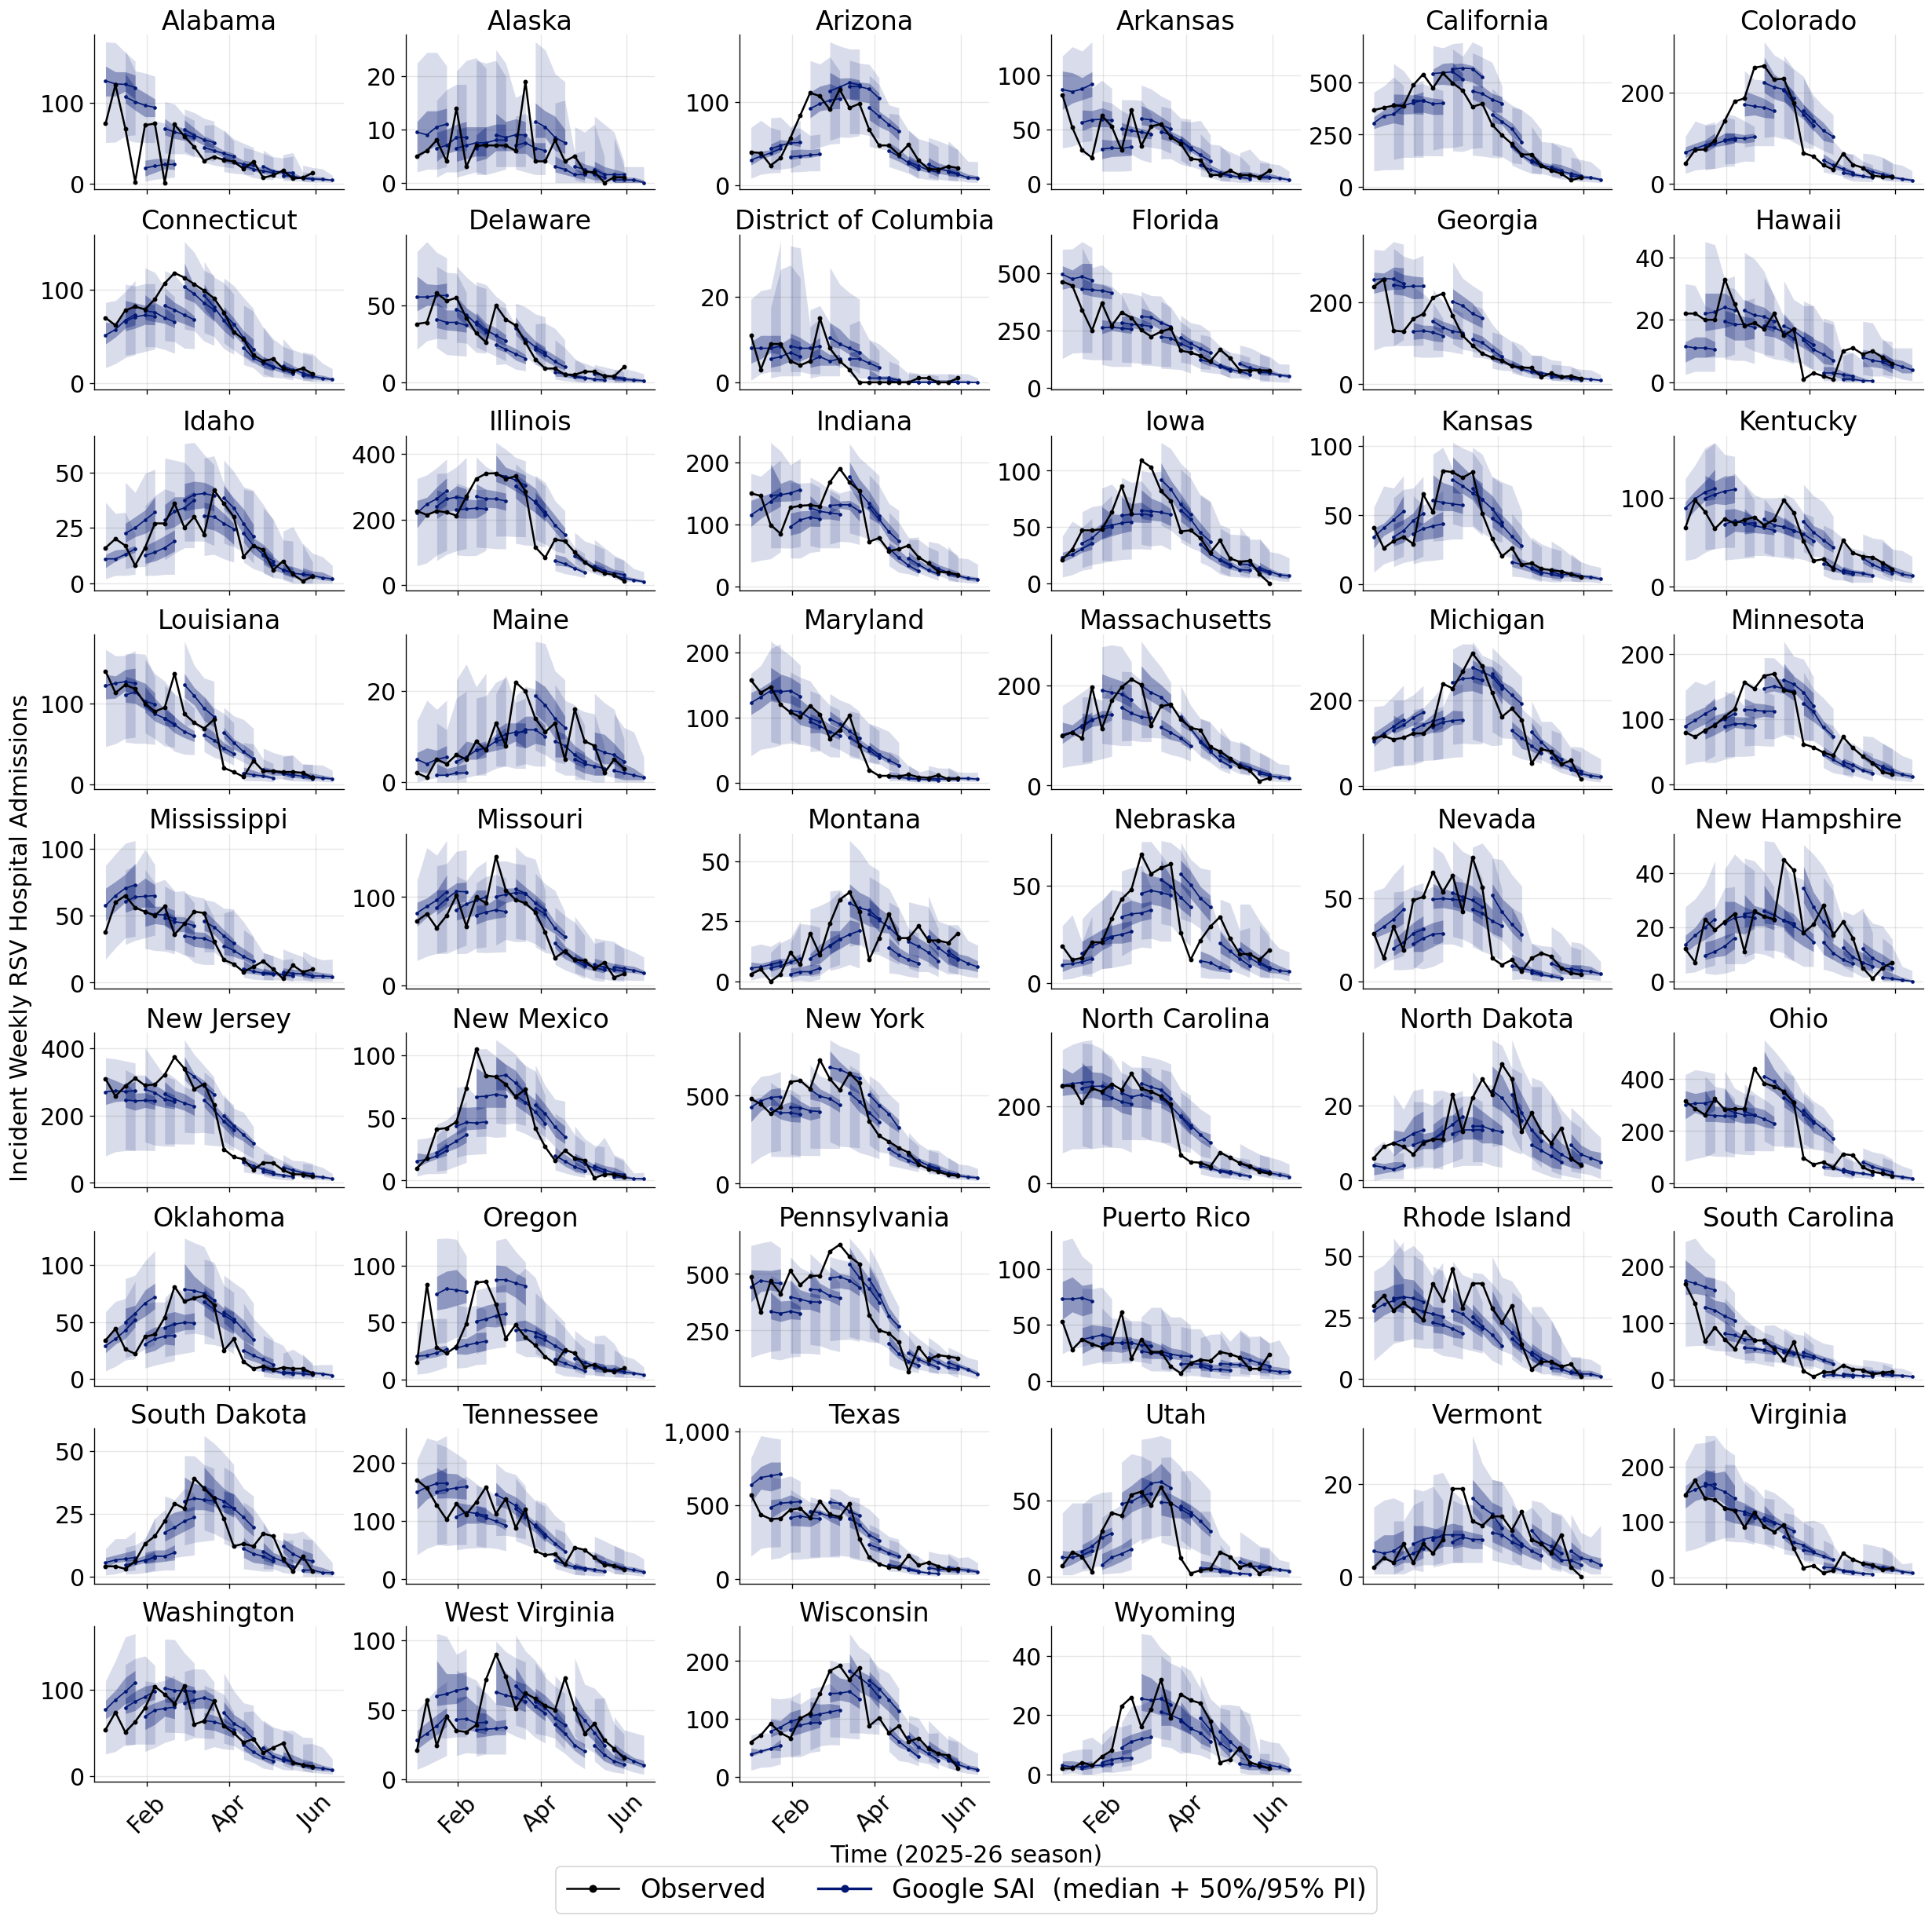

In [31]:
disease = 'rsv'
P.plot_forecast_fans(
    forecasts=rsv_fc,
    truth=rsv_obs,
    model_display=RSV_MODEL_DISPLAY,
    hub_label=RSV_HUB.label,
    location_names=LOCATION_NAMES,
    plot_every_n=2,
    save_path=os.path.join(PLTS_TO+f"/{disease}", f"{disease}_forecasts_over_season.png")
)

---
## Season Average — All Infections

In [32]:
# Load scores for each hub and compute season-average summaries.
# Eligible: ≥ 80% task coverage; Flu also requires mean WIS ≤ 150.
# Plot set: eligible models + hub ensemble/baseline (extra flu ensembles excluded).

ELIGIBILITY_THRESHOLD = 0.80
FLU_MAX_WIS           = 150
EXCLUDE_LOCS          = ["US"]

def _season_summary(hub, max_wis=None):
    scores = pd.read_parquet(hub.scores_path)
    scores = scores[
        (scores["horizon"] != -1) &
        (~scores["location"].isin(EXCLUDE_LOCS))
    ].copy()

    MAX_TASKS = len(scores.groupby(["reference_date", "horizon", "location"]))
    n_tasks   = scores.groupby("model_id").size()
    mean_wis  = scores.groupby("model_id")["wis"].mean()

    elig_mask = n_tasks / MAX_TASKS >= ELIGIBILITY_THRESHOLD
    if max_wis is not None:
        elig_mask &= mean_wis <= max_wis
    eligible = set(elig_mask[elig_mask].index)
    hub_set  = {hub.ensemble_id, hub.baseline_id}

    scores_sub = scores[scores["model_id"].isin(eligible | hub_set)]
    summary = (
        scores_sub
        .groupby("model_id", as_index=False)
        .agg(mean_wis=("wis", "mean"), mean_log_wis=("log_wis", "mean"))
        .sort_values("mean_log_wis")
    )

    rel = (
        S.pairwise_relative_wis(scores_sub, baseline_model=hub.ensemble_id, score_col="log_wis")
        .rename(columns={"rel_wis": "rel_log_wis"})
    )
    summary = summary.merge(rel, on="model_id", how="left")
    rel = (
        S.pairwise_relative_wis(scores_sub, baseline_model=hub.ensemble_id, score_col="wis")
        .rename(columns={"rel_wis": "rel_wis"})
    )
    summary = summary.merge(rel, on="model_id", how="left")

    colours = {
        m: (C.GOOGLE_PINK if m == hub.google_id
            else C.HUB_BLACK if m in hub_set
            else C.OTHER_GREY)
        for m in summary["model_id"]
    }
    hatches = {
        m: (C.HUB_BASELINE_HATCH if m == hub.baseline_id
            else C.HUB_HATCH if m in hub_set
            else "")
        for m in summary["model_id"]
    }

    return summary, colours, hatches

flu_sum,   flu_col,   flu_hat   = _season_summary(FLU_HUB,   max_wis=FLU_MAX_WIS)
covid_sum, covid_col, covid_hat = _season_summary(COVID_HUB)
rsv_sum,   rsv_col,   rsv_hat   = _season_summary(RSV_HUB)

print(f"Flu:   {len(flu_sum)} models")
print(f"COVID: {len(covid_sum)} models")
print(f"RSV:   {len(rsv_sum)} models")

Flu:   43 models
COVID: 11 models
RSV:   4 models


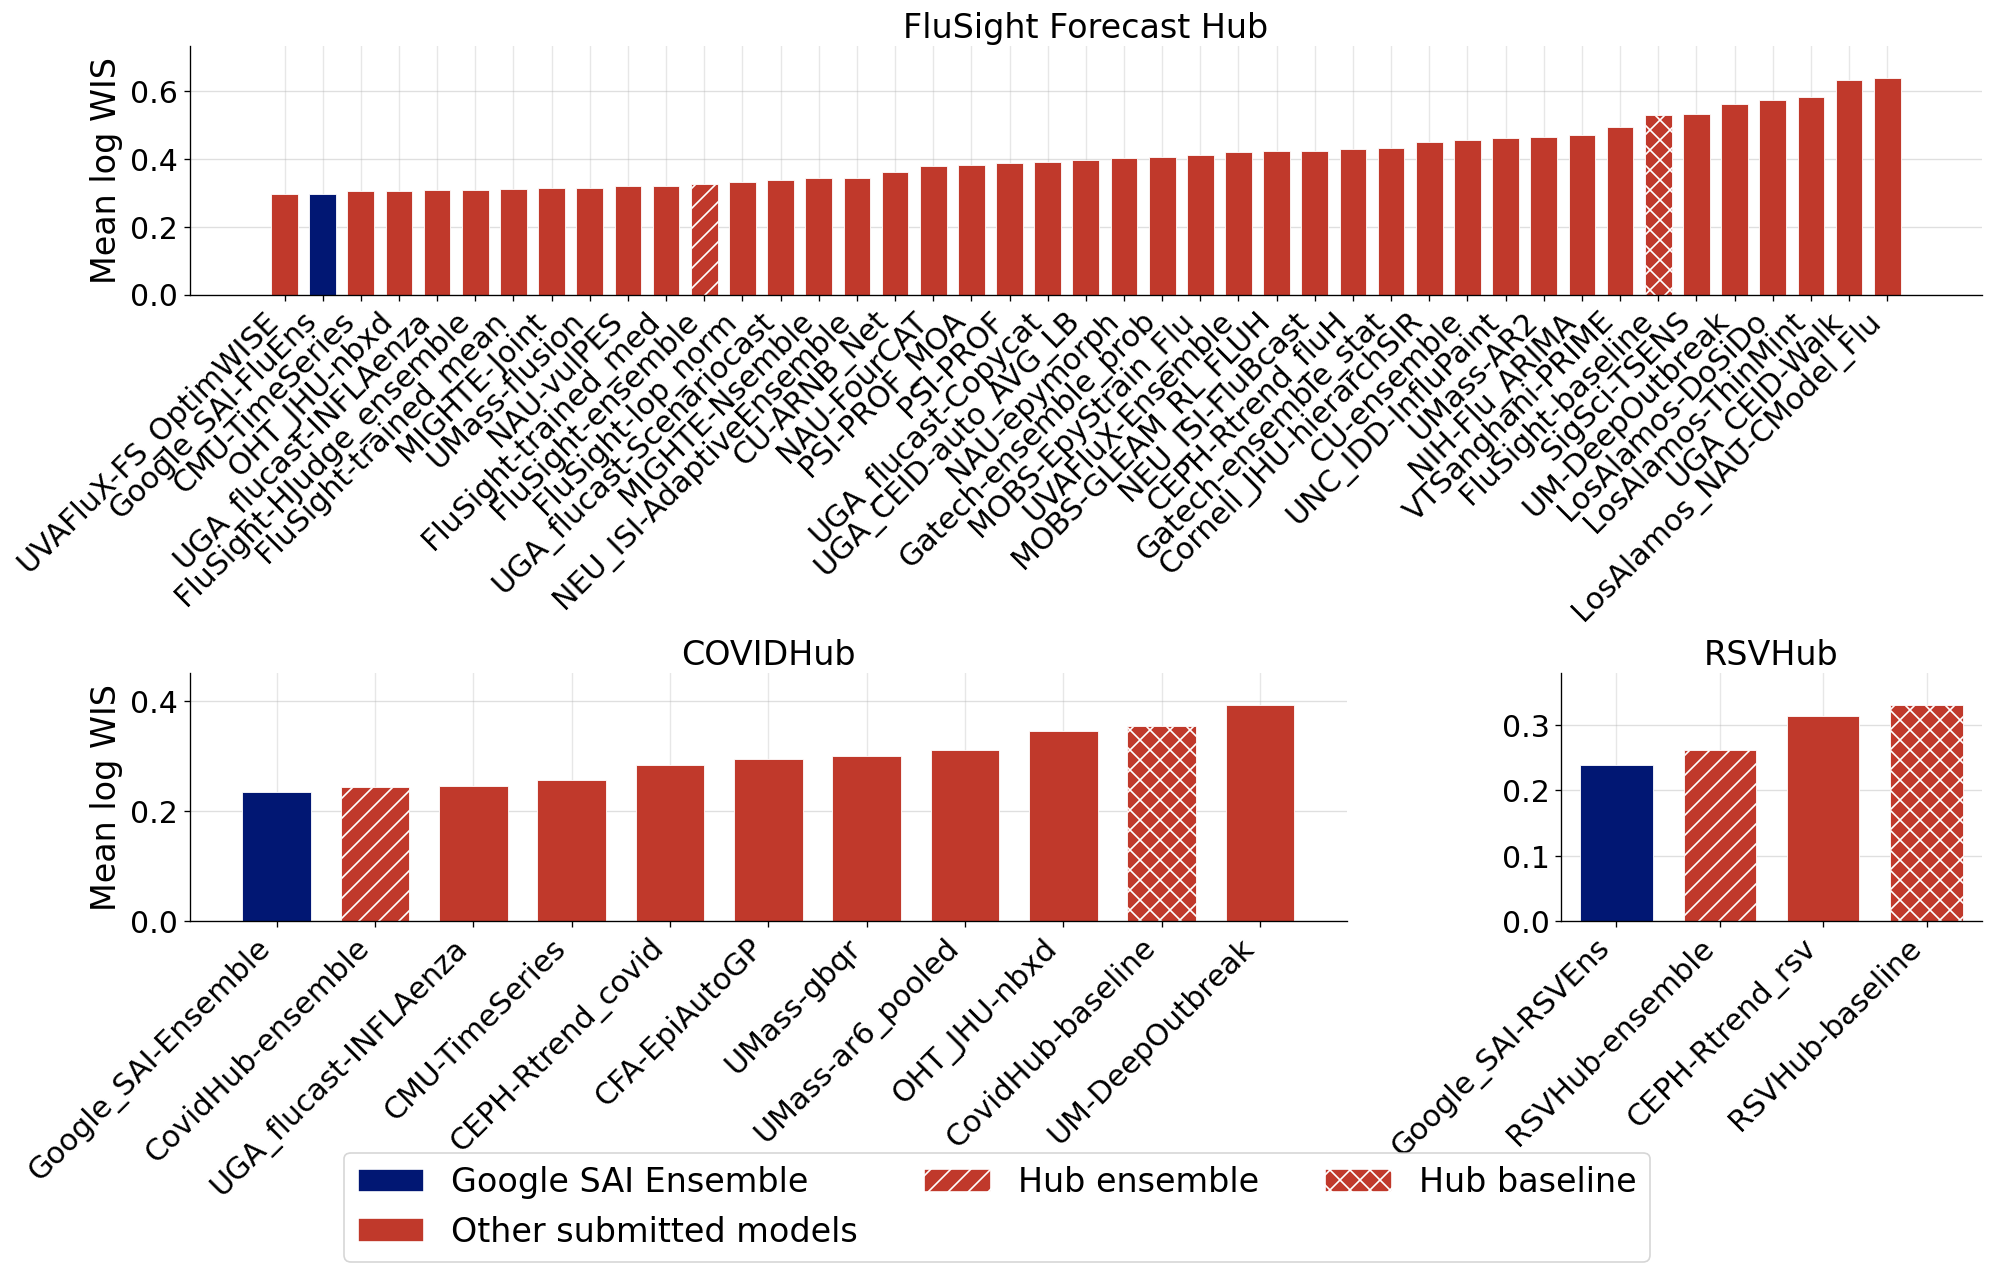

In [40]:
P.plot_combined_season_bars(
    flu_sum, covid_sum, rsv_sum,
    flu_col, covid_col, rsv_col,
    flu_hatches=flu_hat, covid_hatches=covid_hat, rsv_hatches=rsv_hat,
    metric="mean_log_wis",
    save_path=os.path.join(PLTS_TO, "all_season_summary_logwis.png")
)

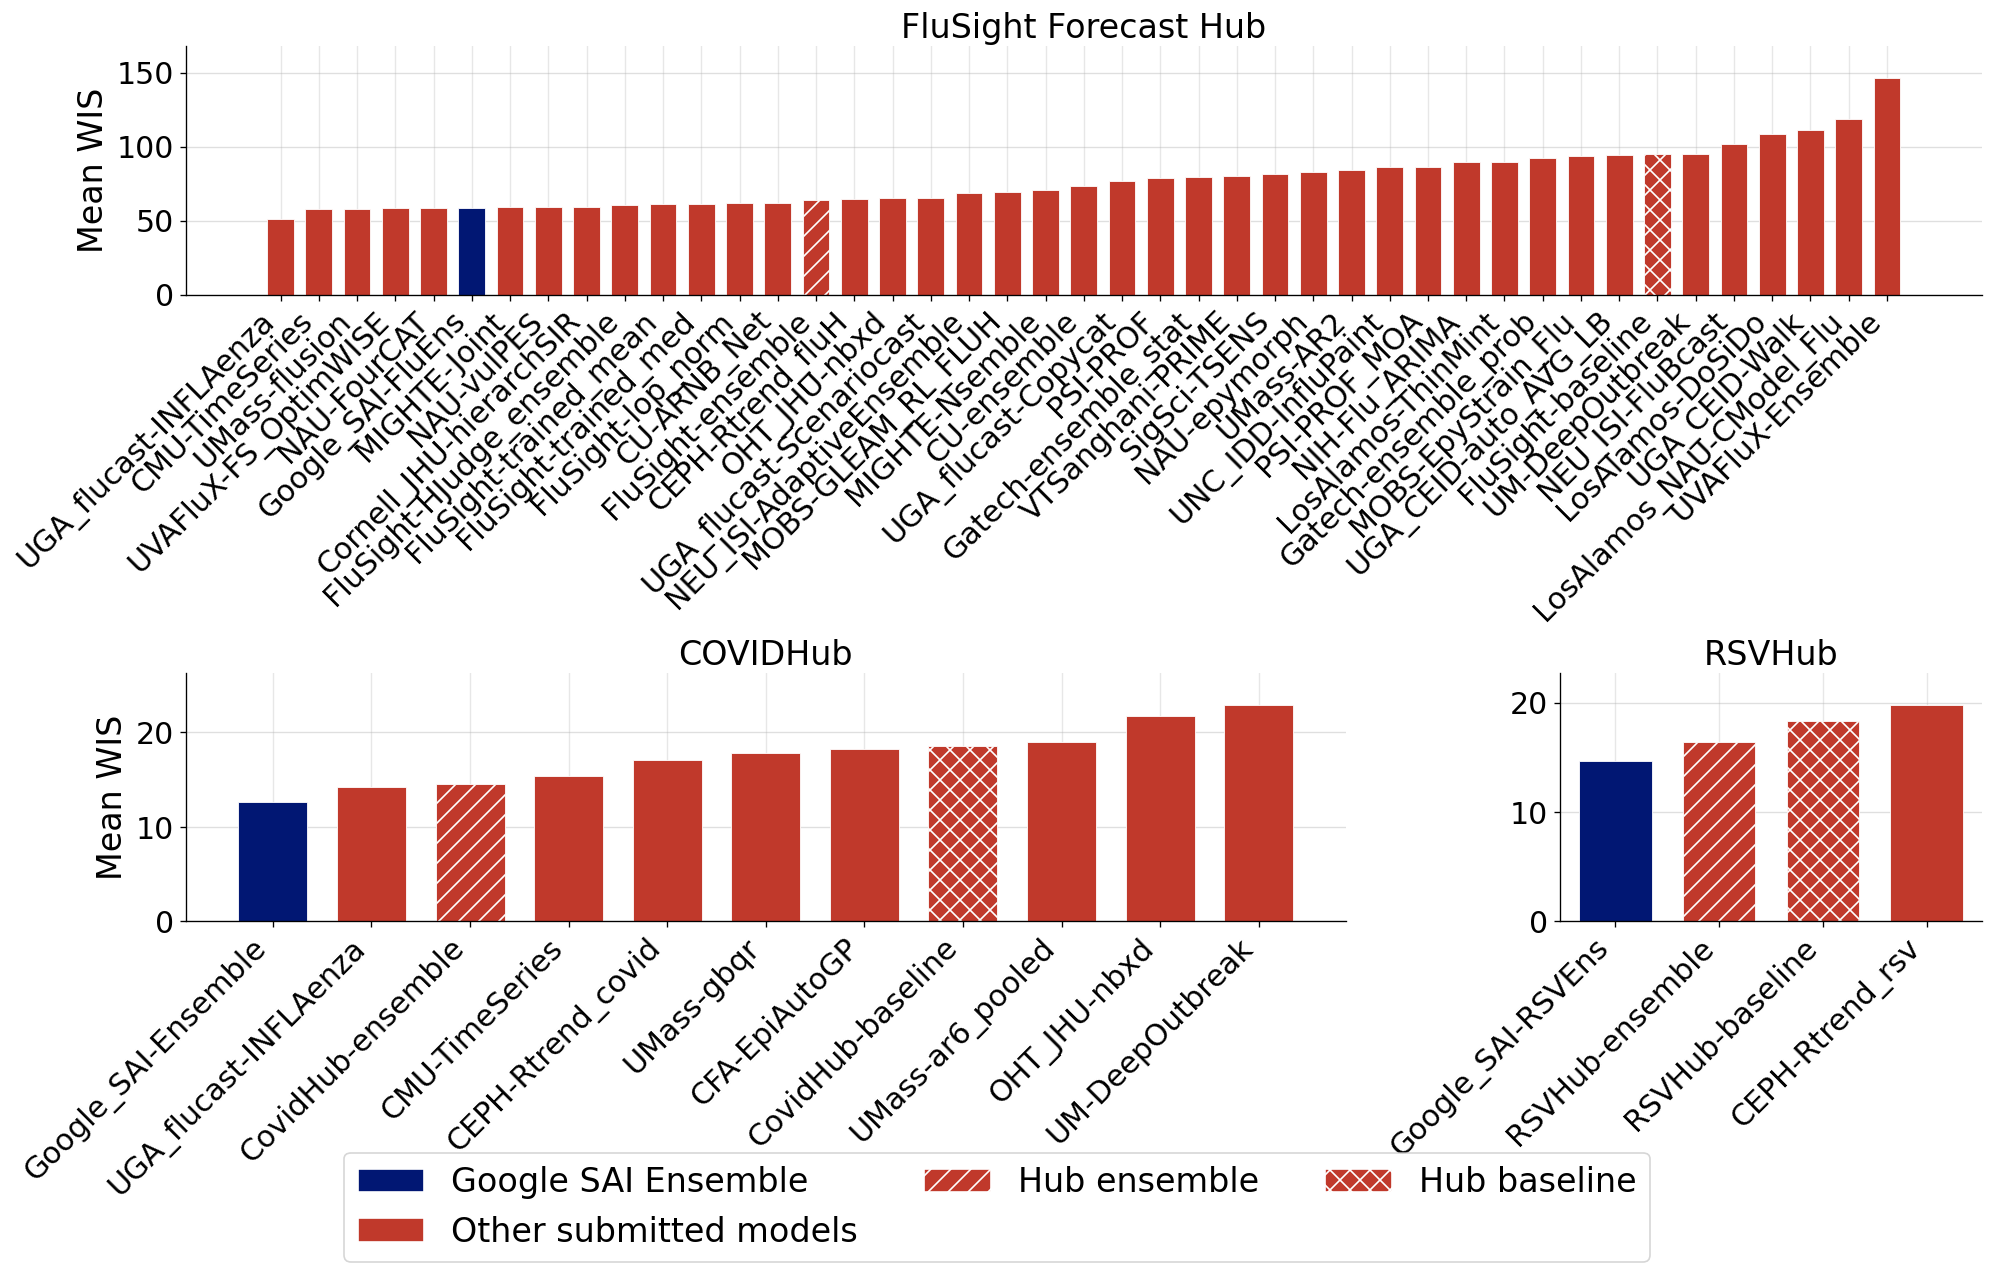

In [34]:
P.plot_combined_season_bars(
    flu_sum, covid_sum, rsv_sum,
    flu_col, covid_col, rsv_col,
    flu_hatches=flu_hat, covid_hatches=covid_hat, rsv_hatches=rsv_hat,
    metric="mean_wis",
    save_path=os.path.join(PLTS_TO, "all_season_summary_wis.png")
)

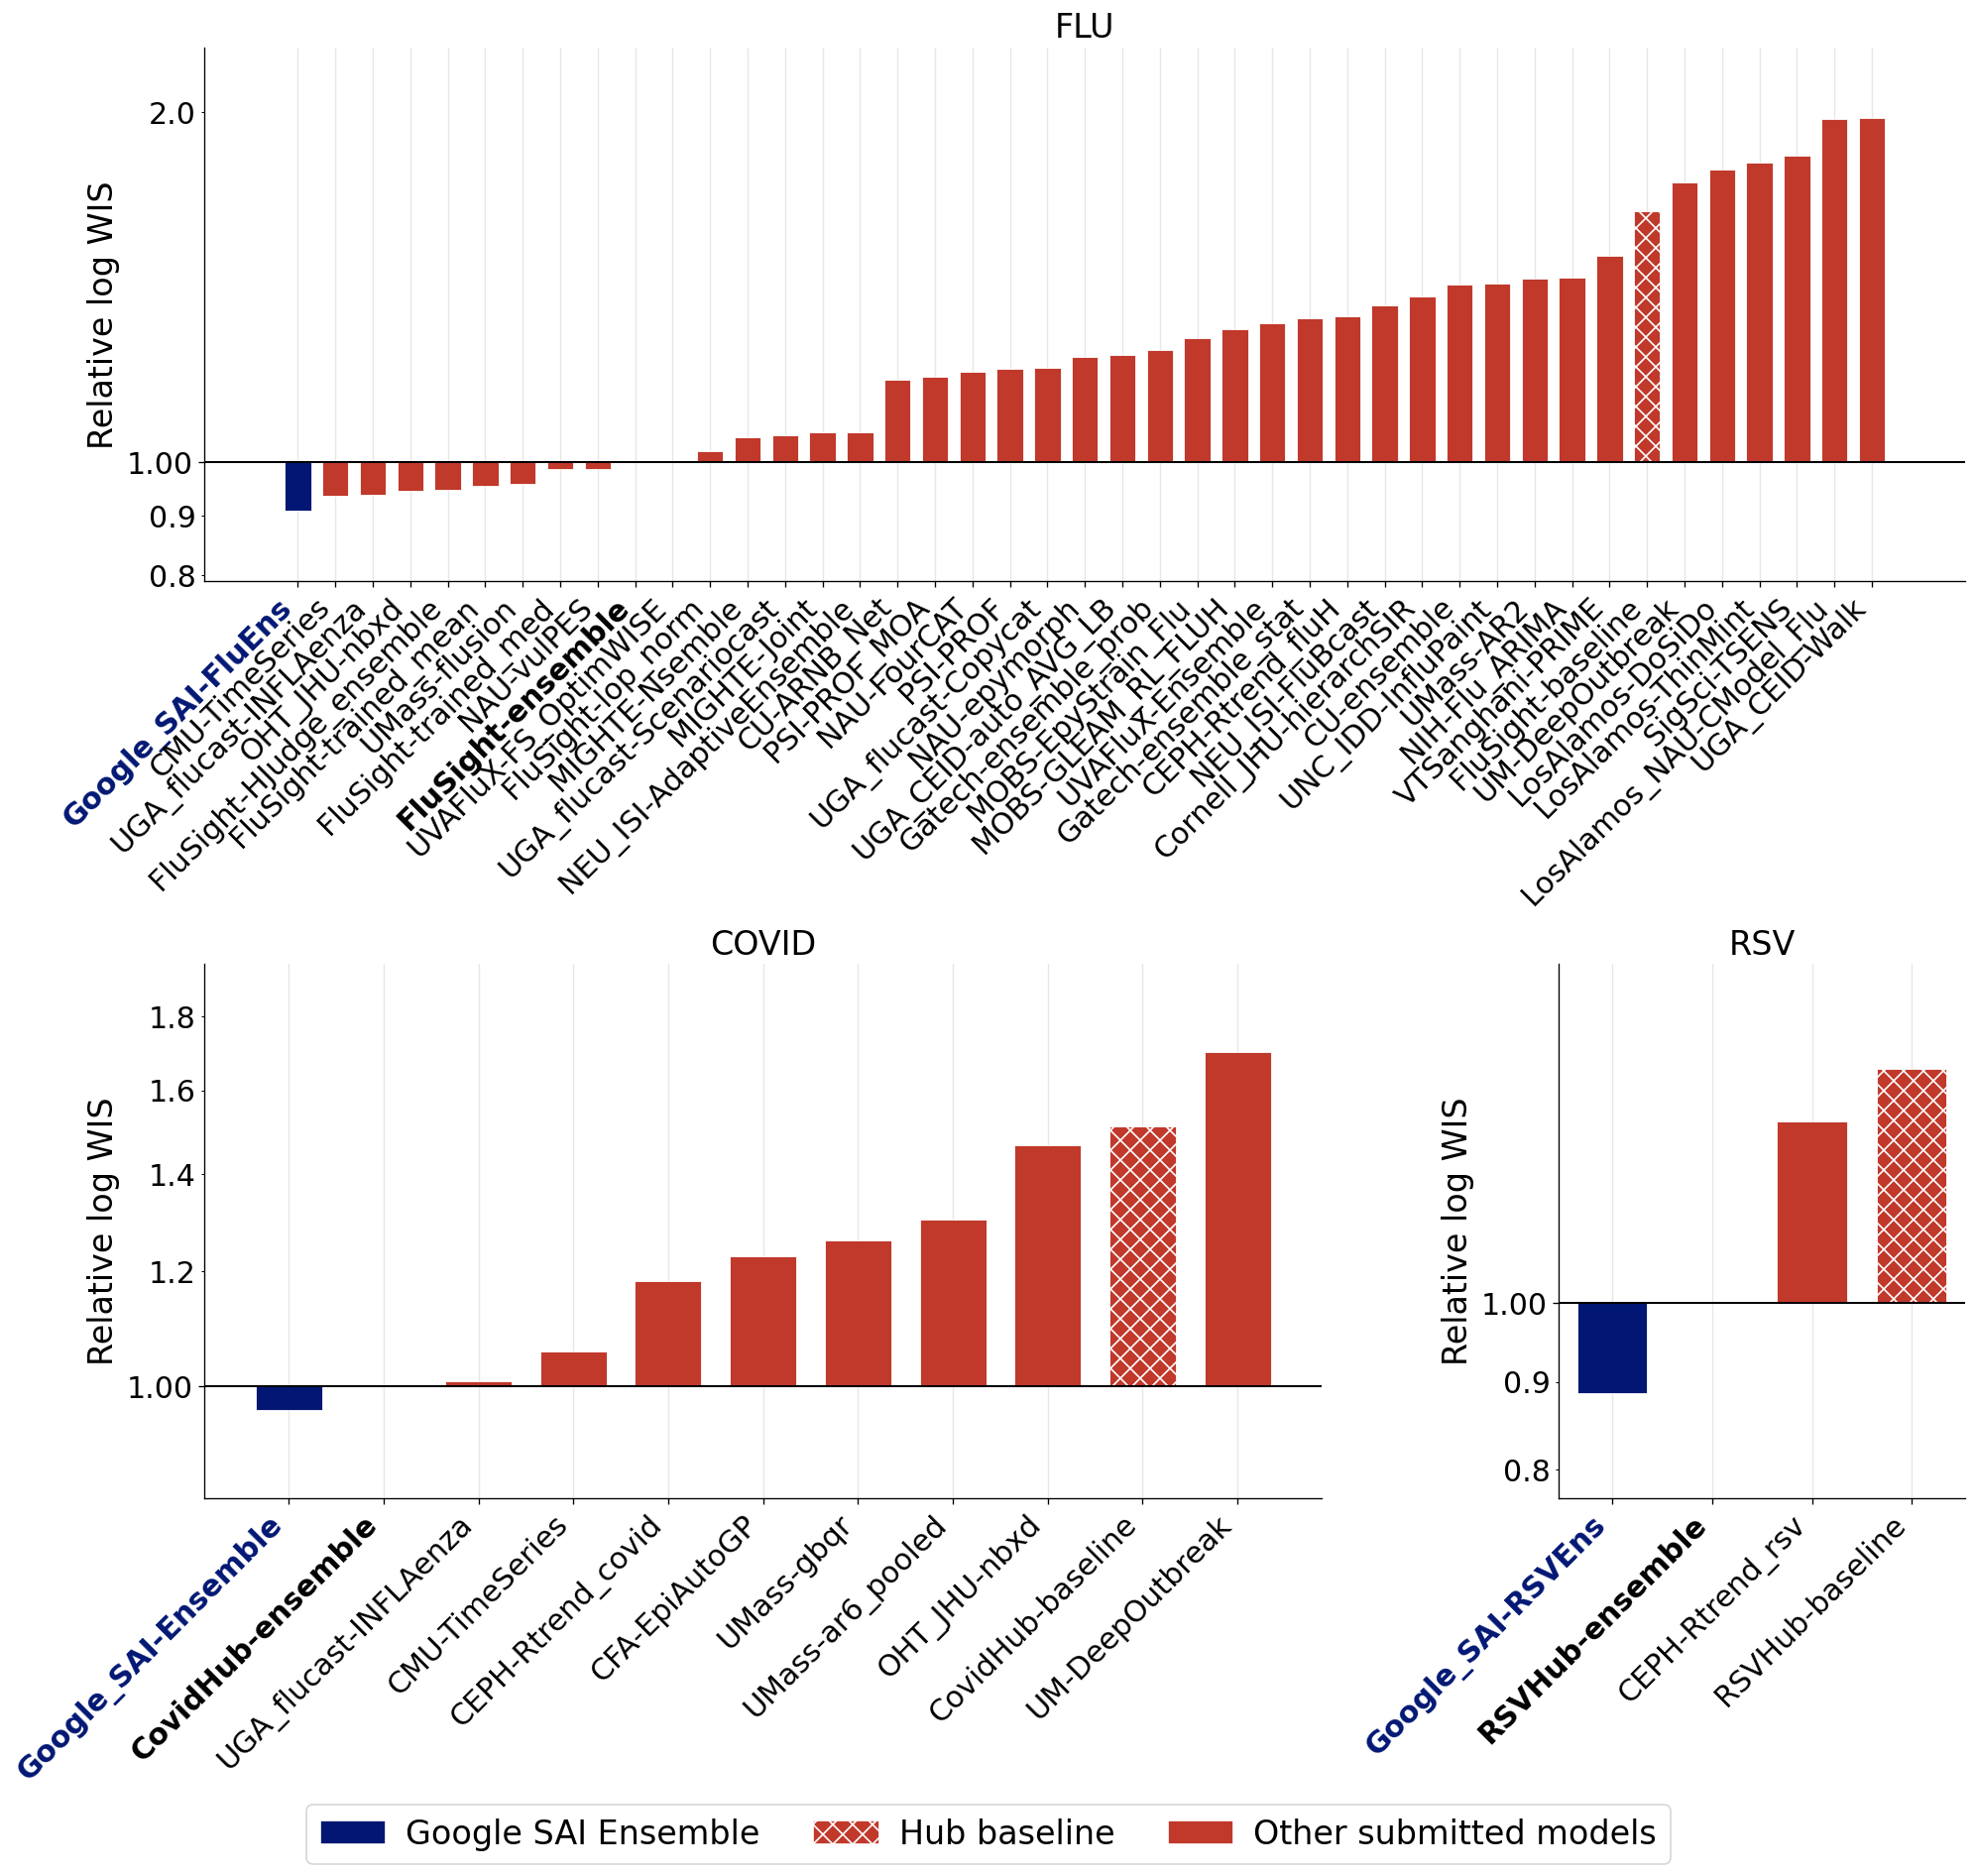

In [41]:
LEGEND_ENTRIES = [
    (C.GOOGLE_PINK, "",         "Google SAI Ensemble"),
    (C.HUB_BLACK,   C.HUB_HATCH,          "Hub ensemble"),
    (C.HUB_BLACK,   C.HUB_BASELINE_HATCH, "Hub baseline"),
    (C.OTHER_GREY,  "",         "Other submitted models"),
]

P.plot_crosshub_rel_bars(
    summaries={"FLU": flu_sum, "COVID": covid_sum, "RSV": rsv_sum},
    colours={"FLU": flu_col, "COVID": covid_col, "RSV": rsv_col},
    hatches={"FLU": flu_hat, "COVID": covid_hat, "RSV": rsv_hat},
    legend_entries=LEGEND_ENTRIES,
    diseases=["FLU", "COVID", "RSV"],
    save_path=os.path.join(PLTS_TO, "all_season_rel_logwis.png"),
    log_scale=True,
)

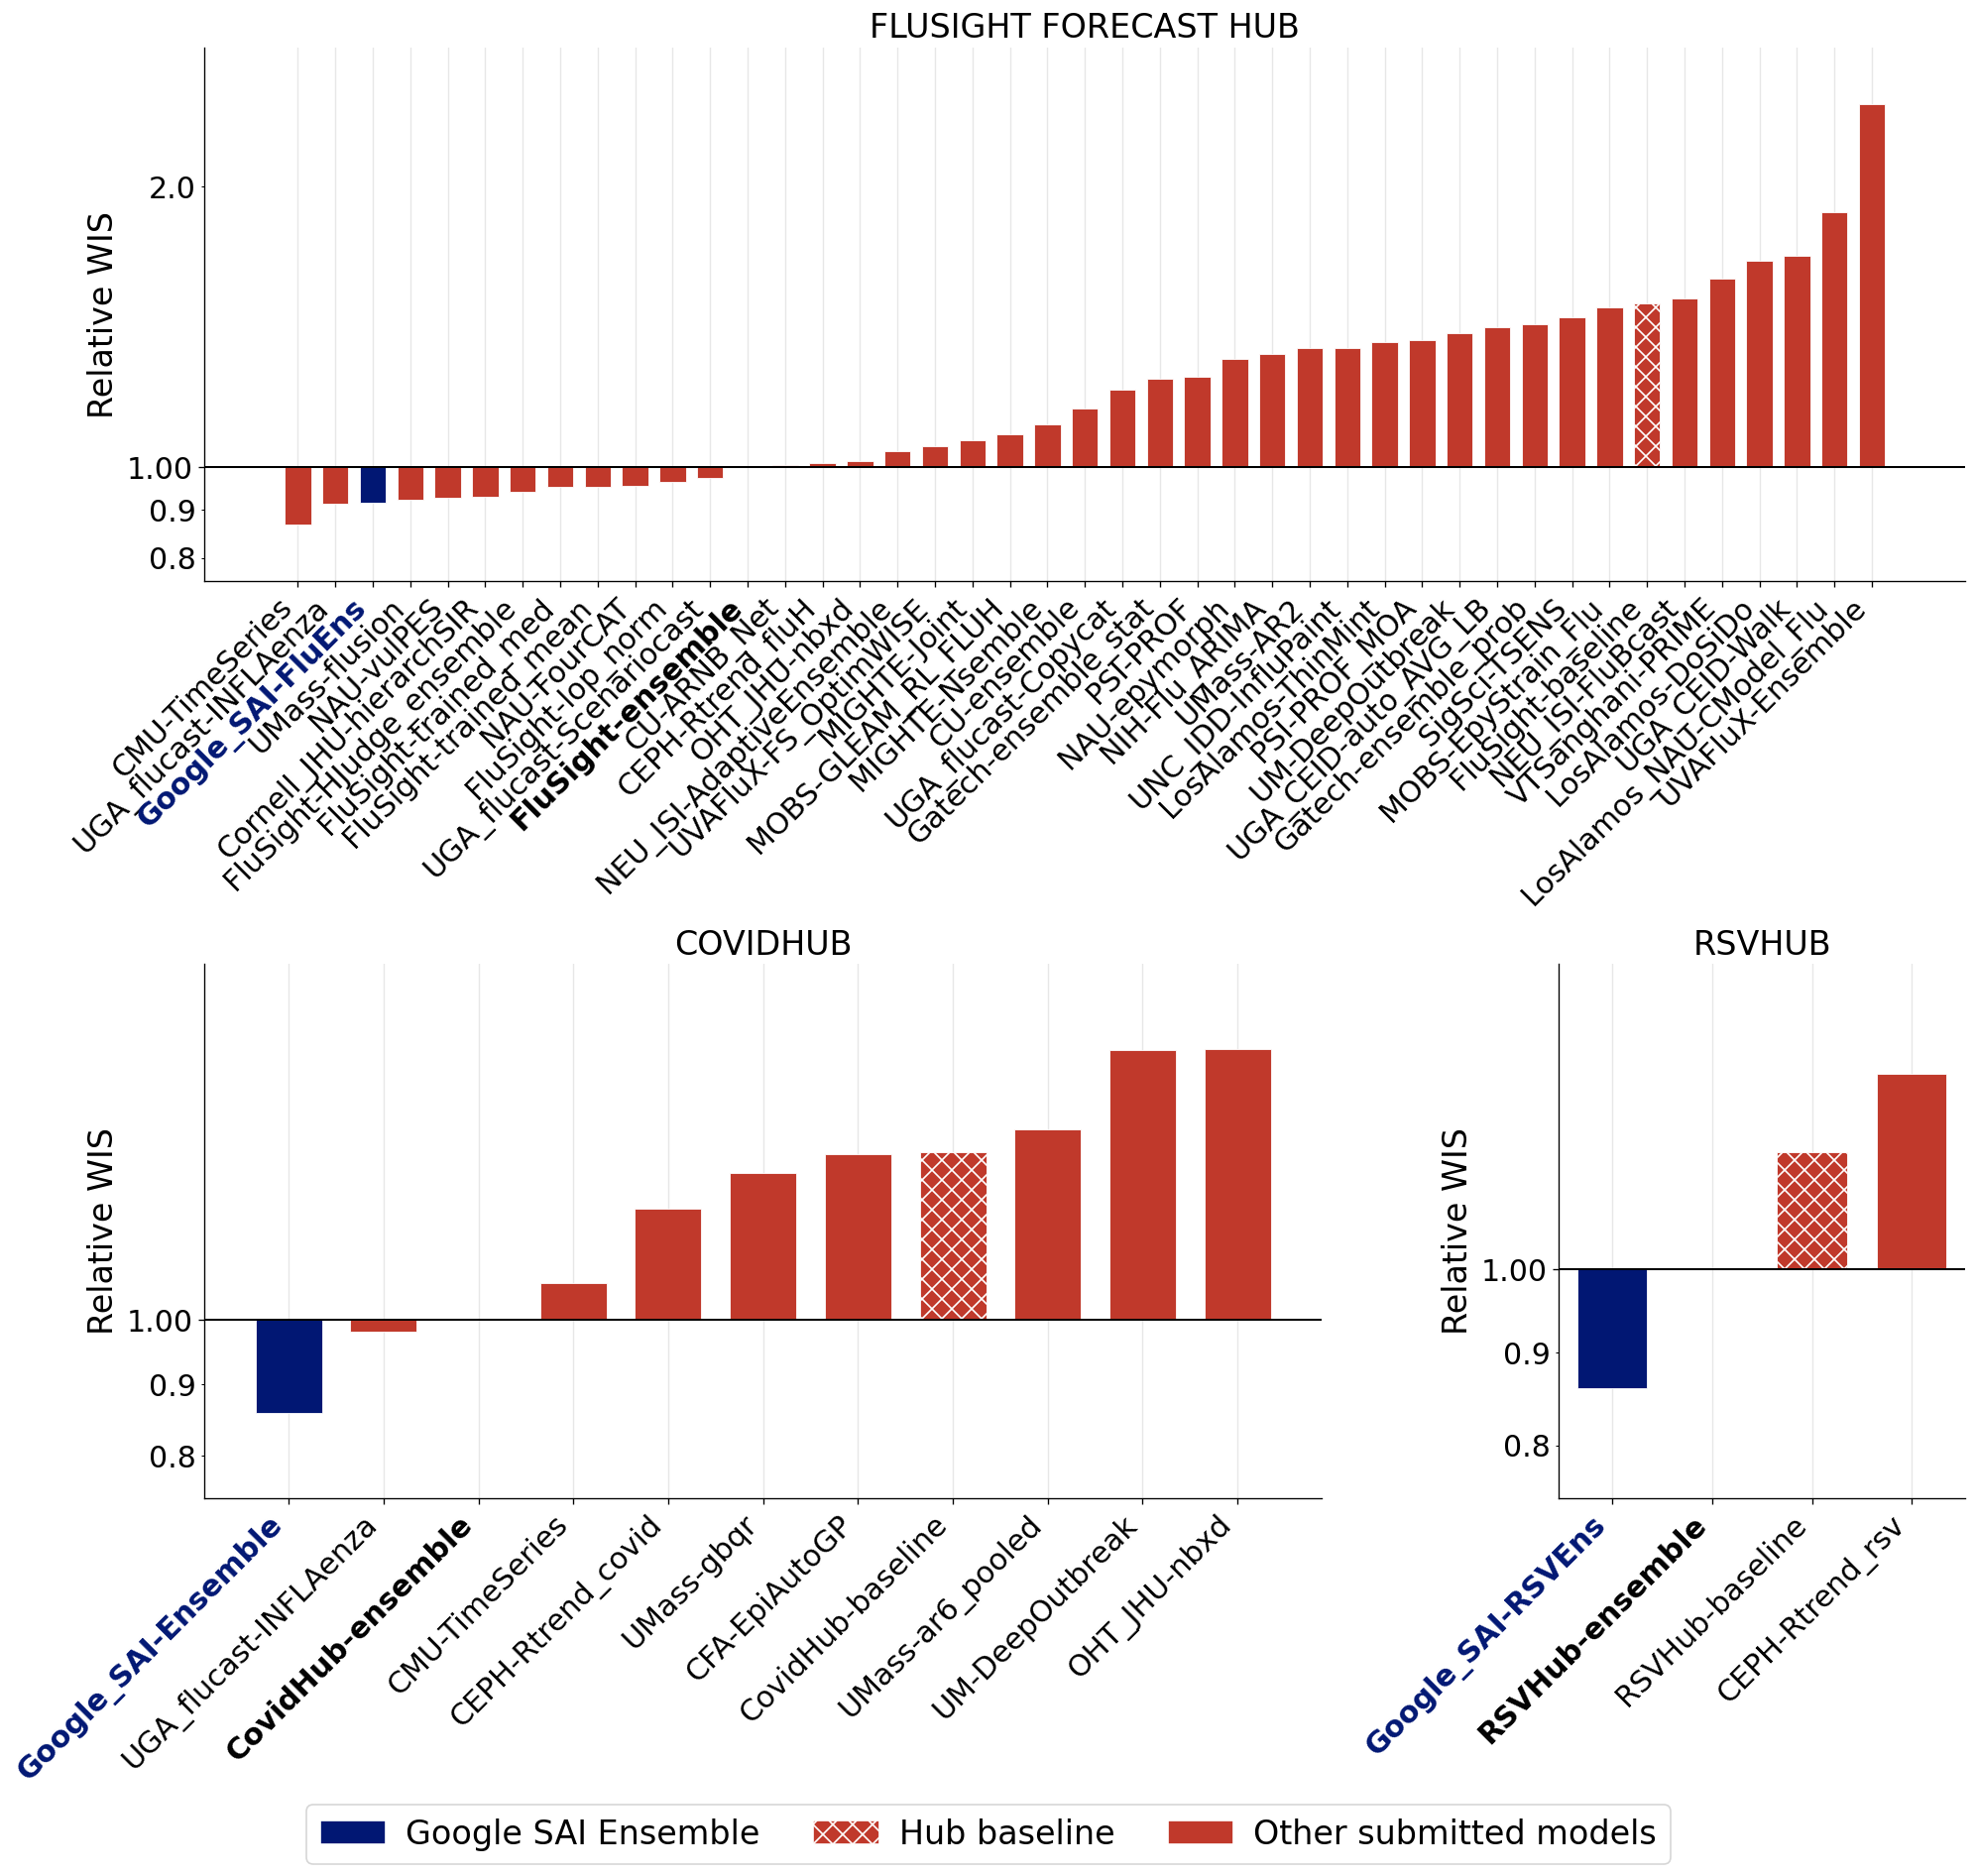

In [38]:
P.plot_crosshub_rel_bars(
    summaries={"FluSight Forecast Hub": flu_sum, "COVIDHub": covid_sum, "RSVHub": rsv_sum},
    colours={"FluSight Forecast Hub": flu_col, "COVIDHub": covid_col, "RSVHub": rsv_col},
    hatches={"FluSight Forecast Hub": flu_hat, "COVIDHub": covid_hat, "RSVHub": rsv_hat},
    legend_entries=LEGEND_ENTRIES,
    metric="rel_wis",
    metric_label="Relative WIS",
    title="Relative WIS vs CDC ensemble (on common tasks)",
    diseases=["FluSight Forecast Hub", "COVIDHub", "RSVHub"],
    save_path=os.path.join(PLTS_TO, "all_season_rel_wis.png"),
    log_scale=True,
)